### First we generate language n-grams

In [103]:
from pathlib import Path
from collections import Counter

import pandas as pd
from nltk.util import ngrams

In [104]:
def generate_character_ngrams(text, n=3):
    text = "_".join(text.lower().split())

    # Generate overlapping character n-grams and count their frequencies
    return Counter(
        ''.join(g)
        for g in ngrams(text, n)
    )

In [105]:
# OUTPUT_DIR = Path("../data/ngrams")
# OUTPUT_DIR.mkdir(exist_ok=True)


# for language, text in corpora.items():
#     counts = generate_character_ngrams(text, 3)

#     df = (
#         pd.DataFrame(
#             counts.items(),
#             columns=["ngram", "frequency"]
#         )
#         .sort_values("frequency", ascending=False)
#         .reset_index(drop=True)
#     )

#     df.to_csv(
#         OUTPUT_DIR / f"{language}_character_trigrams.csv",
#         index=False
#     )

#     print(f"Saved {language}")

### Determining how many trigrams are taken into account

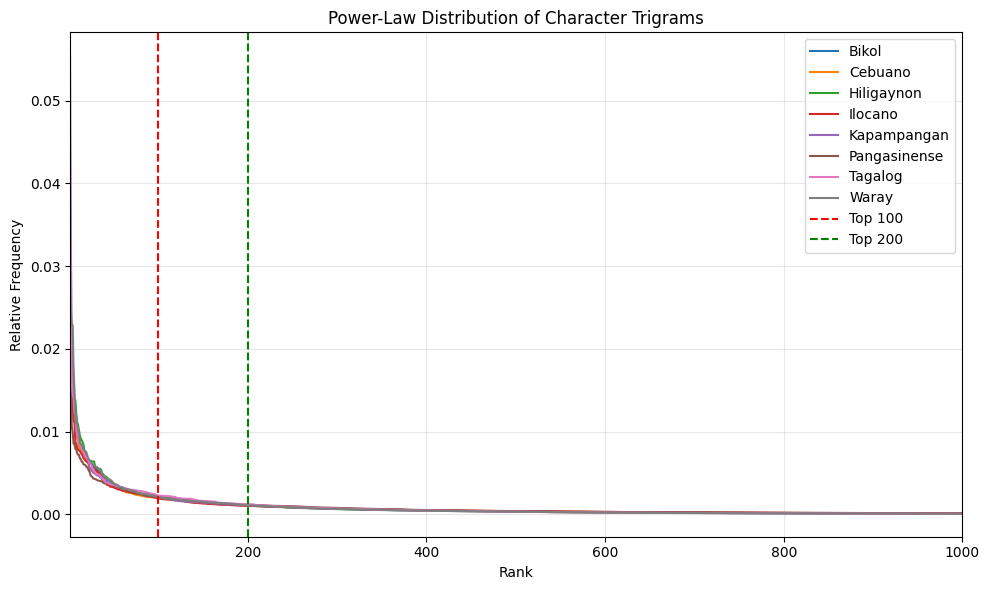

In [106]:
import numpy as np
import matplotlib.pyplot as plt

NGRAM_DIR = Path("../data/ngrams")
MAX_RANK = 1000


plt.figure(figsize=(10, 6))

# Read directly from  CSVs 
for file in NGRAM_DIR.glob("*_character_trigrams.csv"):
    language = file.stem.replace("_character_trigrams", "")
    
    df = pd.read_csv(file, na_filter=False)
    
   
    total_ngrams = df["frequency"].sum()
    df["relative_frequency"] = df["frequency"] / total_ngrams
    
    plot_data = df["relative_frequency"].head(MAX_RANK)
    
    
    plt.plot(range(1, len(plot_data) + 1), plot_data, label=language)

plt.axvline(100, color='red', linestyle='--', label='Top 100')
plt.axvline(200, color='green', linestyle='--', label='Top 200')

plt.xlabel("Rank")
plt.ylabel("Relative Frequency")
plt.title("Power-Law Distribution of Character Trigrams")
plt.xlim(1, MAX_RANK)


plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [107]:
from pathlib import Path
import pandas as pd
import numpy as np

NGRAM_DIR = Path("../data/ngrams")

TOP_K = 100

language_vectors = {}
vocabulary = set()

# Read the top-k trigrams from every language
for file in NGRAM_DIR.glob("*_character_trigrams.csv"):
    language = file.stem.replace("_character_trigrams", "")

    df = (
        pd.read_csv(file,na_filter=False)
        .head(TOP_K)
    )

    freq_dict = dict(zip(df["ngram"], df["frequency"]))

    language_vectors[language] = freq_dict
    vocabulary.update(freq_dict.keys())

vocabulary = sorted(vocabulary)

print(f"{len(language_vectors)} languages")
print(f"{len(vocabulary)} unique trigrams")

8 languages
282 unique trigrams


In [108]:
aligned_vectors = {}

for language, freq_dict in language_vectors.items():
    aligned_vectors[language] = np.array([
        freq_dict.get(trigram, 0)
        for trigram in vocabulary
    ])

In [109]:
from sklearn.metrics.pairwise import cosine_similarity

languages = list(aligned_vectors.keys())

matrix = np.vstack([
    aligned_vectors[lang]
    for lang in languages
])

cosine_matrix = cosine_similarity(matrix)

cosine_df = pd.DataFrame(
    cosine_matrix,
    index=languages,
    columns=languages
)

cosine_df

,Bikol,Cebuano,Hiligaynon,Ilocano,Kapampangan,Pangasinense,Tagalog,Waray
Bikol,1.000000,0.754973,0.720740,0.383800,0.488108,0.673207,0.718196,0.733554
Cebuano,0.754973,1.000000,0.889493,0.337257,0.563663,0.517878,0.841647,0.717415
Hiligaynon,0.720740,0.889493,1.000000,0.352590,0.535793,0.499201,0.822082,0.758534
Ilocano,0.383800,0.337257,0.352590,1.000000,0.272462,0.449432,0.336011,0.358884
Kapampangan,0.488108,0.563663,0.535793,0.272462,1.000000,0.382953,0.729665,0.281373
Pangasinense,0.673207,0.517878,0.499201,0.449432,0.382953,1.000000,0.498926,0.592472
Tagalog,0.718196,0.841647,0.822082,0.336011,0.729665,0.498926,1.000000,0.568986
Waray,0.733554,0.717415,0.758534,0.358884,0.281373,0.592472,0.568986,1.000000


In [110]:
def dice_similarity(x, y):
    x = x > 0
    y = y > 0

    intersection = np.sum(x & y)

    return (2 * intersection) / (np.sum(x) + np.sum(y))

In [111]:
dice_matrix = np.zeros((len(languages), len(languages)))

for i, lang1 in enumerate(languages):
    for j, lang2 in enumerate(languages):
        dice_matrix[i, j] = dice_similarity(
            aligned_vectors[lang1],
            aligned_vectors[lang2]
        )

dice_df = pd.DataFrame(
    dice_matrix,
    index=languages,
    columns=languages
)

dice_df

,Bikol,Cebuano,Hiligaynon,Ilocano,Kapampangan,Pangasinense,Tagalog,Waray
Bikol,1.00,0.64,0.66,0.45,0.44,0.48,0.60,0.64
Cebuano,0.64,1.00,0.71,0.43,0.48,0.48,0.64,0.62
Hiligaynon,0.66,0.71,1.00,0.43,0.41,0.48,0.61,0.66
Ilocano,0.45,0.43,0.43,1.00,0.41,0.56,0.47,0.43
Kapampangan,0.44,0.48,0.41,0.41,1.00,0.48,0.52,0.38
Pangasinense,0.48,0.48,0.48,0.56,0.48,1.00,0.50,0.52
Tagalog,0.60,0.64,0.61,0.47,0.52,0.50,1.00,0.53
Waray,0.64,0.62,0.66,0.43,0.38,0.52,0.53,1.00


In [112]:
def extended_jaccard(x, y):
    numerator = np.dot(x, y)

    denominator = (
        np.dot(x, x)
        + np.dot(y, y)
        - numerator
    )

    return numerator / denominator

In [113]:
jaccard_matrix = np.zeros((len(languages), len(languages)))

for i, lang1 in enumerate(languages):
    for j, lang2 in enumerate(languages):
        jaccard_matrix[i, j] = extended_jaccard(
            aligned_vectors[lang1],
            aligned_vectors[lang2]
        )

jaccard_df = pd.DataFrame(
    jaccard_matrix,
    index=languages,
    columns=languages
)

jaccard_df

,Bikol,Cebuano,Hiligaynon,Ilocano,Kapampangan,Pangasinense,Tagalog,Waray
Bikol,1.000000,0.562029,0.558769,0.213361,0.289229,0.457590,0.525521,0.234934
Cebuano,0.562029,1.000000,0.692016,0.151240,0.389497,0.261902,0.549229,0.164016
Hiligaynon,0.558769,0.692016,1.000000,0.201310,0.307958,0.316593,0.677672,0.273067
Ilocano,0.213361,0.151240,0.201310,1.000000,0.110029,0.289448,0.199774,0.149008
Kapampangan,0.289229,0.389497,0.307958,0.110029,1.000000,0.167872,0.407525,0.052837
Pangasinense,0.457590,0.261902,0.316593,0.289448,0.167872,1.000000,0.330691,0.261383
Tagalog,0.525521,0.549229,0.677672,0.199774,0.407525,0.330691,1.000000,0.229414
Waray,0.234934,0.164016,0.273067,0.149008,0.052837,0.261383,0.229414,1.000000


In [114]:
def overlap_similarity(x, y):
    x = x > 0
    y = y > 0

    intersection = np.sum(x & y)

    return intersection / min(np.sum(x), np.sum(y))

In [115]:
overlap_matrix = np.zeros((len(languages), len(languages)))

for i, lang1 in enumerate(languages):
    for j, lang2 in enumerate(languages):
        overlap_matrix[i, j] = overlap_similarity(
            aligned_vectors[lang1],
            aligned_vectors[lang2]
        )

overlap_df = pd.DataFrame(
    overlap_matrix,
    index=languages,
    columns=languages
)

overlap_df

,Bikol,Cebuano,Hiligaynon,Ilocano,Kapampangan,Pangasinense,Tagalog,Waray
Bikol,1.00,0.64,0.66,0.45,0.44,0.48,0.60,0.64
Cebuano,0.64,1.00,0.71,0.43,0.48,0.48,0.64,0.62
Hiligaynon,0.66,0.71,1.00,0.43,0.41,0.48,0.61,0.66
Ilocano,0.45,0.43,0.43,1.00,0.41,0.56,0.47,0.43
Kapampangan,0.44,0.48,0.41,0.41,1.00,0.48,0.52,0.38
Pangasinense,0.48,0.48,0.48,0.56,0.48,1.00,0.50,0.52
Tagalog,0.60,0.64,0.61,0.47,0.52,0.50,1.00,0.53
Waray,0.64,0.62,0.66,0.43,0.38,0.52,0.53,1.00


In [116]:
def check_similarity_matrix(df, name):
    print(f"\n{name}")
    print("Diagonal:", np.diag(df))
    print("Min:", df.values.min())
    print("Max:", df.values.max())
    print("Symmetric:", np.allclose(df.values, df.values.T))

In [117]:
check_similarity_matrix(cosine_df, "Cosine")
check_similarity_matrix(dice_df, "Dice")
check_similarity_matrix(jaccard_df, "Extended Jaccard")
check_similarity_matrix(overlap_df, "Overlap")


Cosine
Diagonal: [1. 1. 1. 1. 1. 1. 1. 1.]
Min: 0.27246188265855753
Max: 1.0
Symmetric: True

Dice
Diagonal: [1. 1. 1. 1. 1. 1. 1. 1.]
Min: 0.38
Max: 1.0
Symmetric: True

Extended Jaccard
Diagonal: [1. 1. 1. 1. 1. 1. 1. 1.]
Min: 0.05283654665632559
Max: 1.0
Symmetric: True

Overlap
Diagonal: [1. 1. 1. 1. 1. 1. 1. 1.]
Min: 0.38
Max: 1.0
Symmetric: True


In [118]:
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import squareform

LINKAGE_METHODS = ["single", "complete", "average"]

def compute_linkages(similarity_matrix):
    """
    Computes hierarchical clustering linkages from a similarity matrix.

    Parameters
    ----------
    similarity_matrix : pd.DataFrame
        Square similarity matrix with values in [0, 1].

    Returns
    -------
    dict
        Dictionary of linkage matrices keyed by linkage method.
    """

    # Convert similarity to distance
    distance_matrix = 1 - similarity_matrix

    # Convert to condensed distance matrix
    condensed = squareform(distance_matrix.values, checks=False)

    linkages = {}

    for method in LINKAGE_METHODS:
        linkages[method] = linkage(condensed, method=method)

    return linkages

In [119]:
cosine_linkages = compute_linkages(cosine_df)
dice_linkages = compute_linkages(dice_df)
extended_jaccard_linkages = compute_linkages(jaccard_df)
overlap_linkages = compute_linkages(overlap_df)

In [120]:
for method, Z in cosine_linkages.items():
    print(f"\n=== Cosine ({method}) ===")
    print(pd.DataFrame(
        Z,
        columns=[
            "Cluster 1",
            "Cluster 2",
            "Distance",
            "Cluster Size"
        ]
    ))


=== Cosine (single) ===
   Cluster 1  Cluster 2  Distance  Cluster Size
0        1.0        2.0  0.110507           2.0
1        6.0        8.0  0.158353           3.0
2        7.0        9.0  0.241466           4.0
3        0.0       10.0  0.245027           5.0
4        4.0       11.0  0.270335           6.0
5        5.0       12.0  0.326793           7.0
6        3.0       13.0  0.550568           8.0

=== Cosine (complete) ===
   Cluster 1  Cluster 2  Distance  Cluster Size
0        1.0        2.0  0.110507           2.0
1        6.0        8.0  0.177918           3.0
2        0.0        7.0  0.266446           2.0
3        5.0       10.0  0.407528           3.0
4        4.0        9.0  0.464207           4.0
5        3.0       11.0  0.641116           4.0
6       12.0       13.0  0.727538           8.0

=== Cosine (average) ===
   Cluster 1  Cluster 2  Distance  Cluster Size
0        1.0        2.0  0.110507           2.0
1        6.0        8.0  0.168136           3.0
2        0

In [121]:
from scipy.cluster.hierarchy import dendrogram
import matplotlib.pyplot as plt

def plot_dendrogram(linkages, title):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, (method, Z) in zip(axes, linkages.items()):
        dendrogram(
            Z,
            labels=languages,
            leaf_rotation=90,
            ax=ax
        )
        ax.set_title(f"{title} ({method})")
        ax.set_ylabel("Distance")

    plt.tight_layout()
    plt.show()

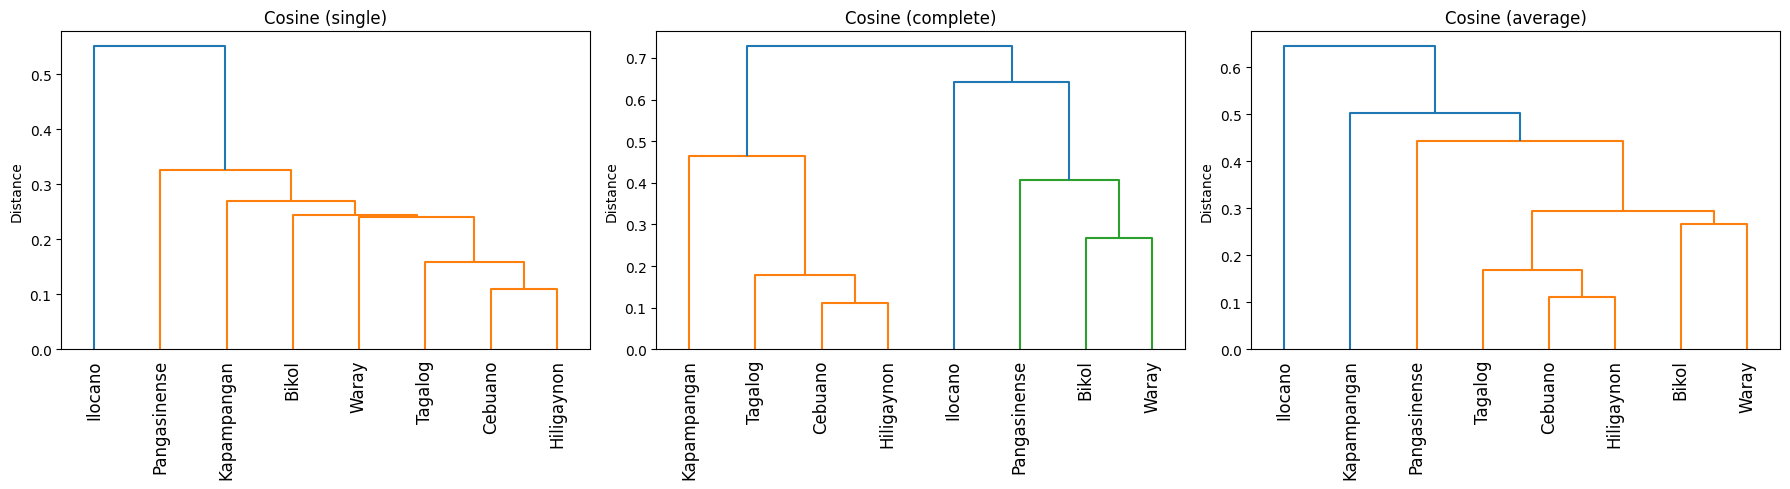

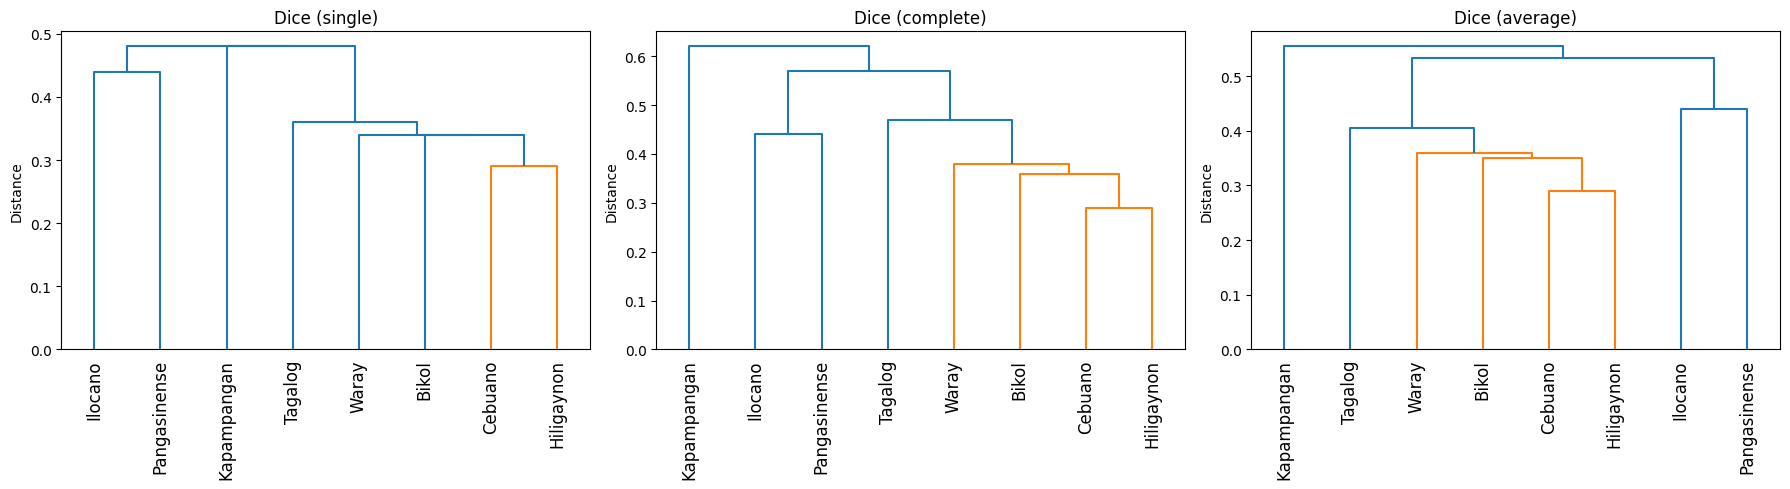

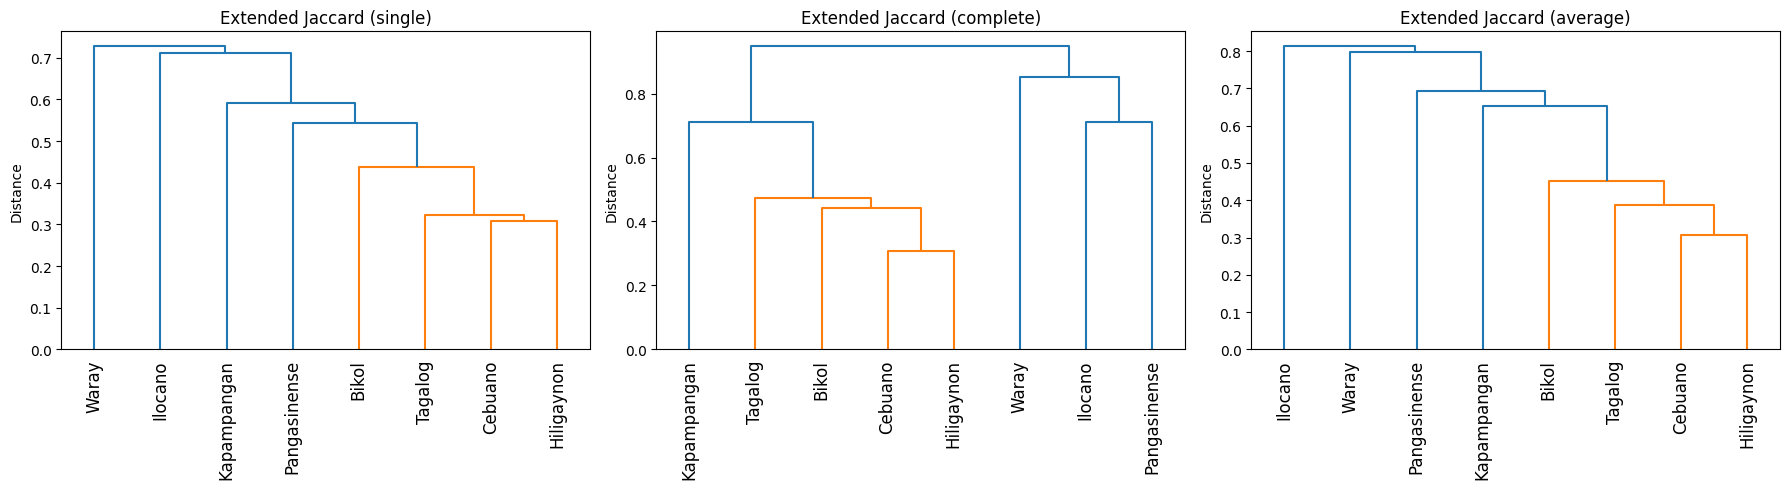

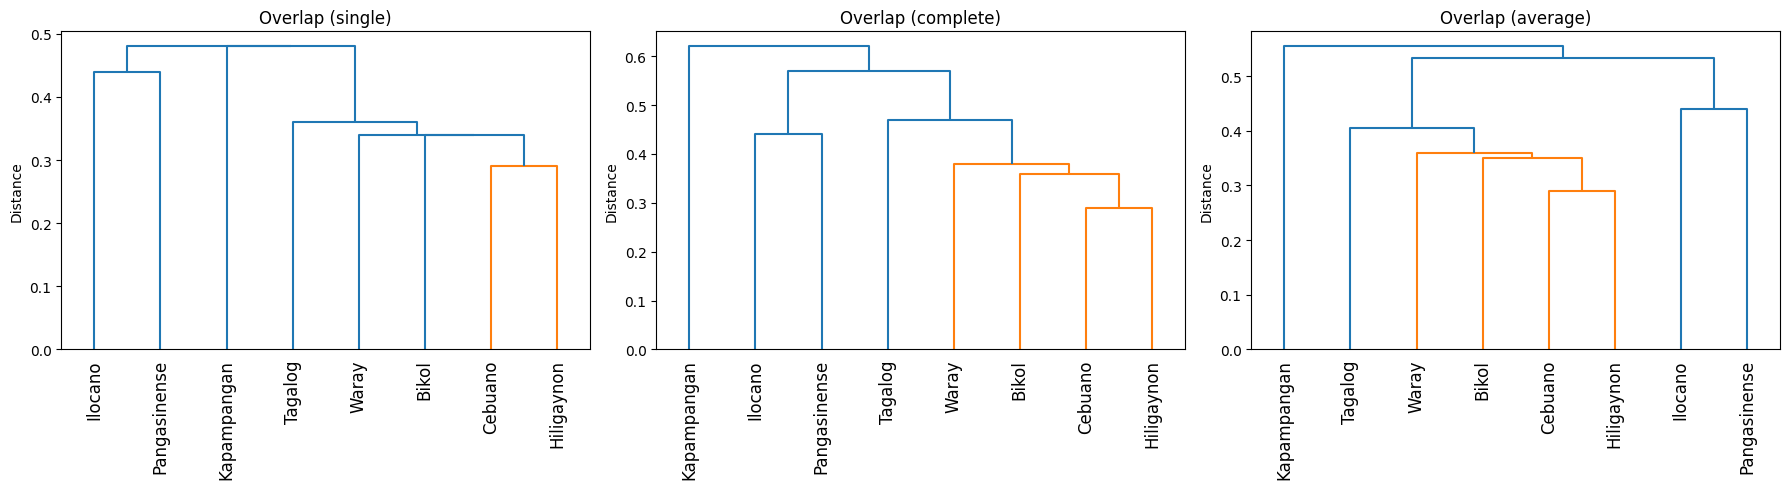

In [122]:
plot_dendrogram(cosine_linkages, "Cosine")
plot_dendrogram(dice_linkages, "Dice")
plot_dendrogram(extended_jaccard_linkages, "Extended Jaccard")
plot_dendrogram(overlap_linkages, "Overlap")

### Digitize Ethnologue Grouping

In [123]:
import networkx as nx
import numpy as np
import pandas as pd
from scipy.spatial.distance import squareform

# 1. Recreate the Ethnologue tree from the image using edges
G = nx.Graph()
edges = [
    ("Philippine", "Northern Luzon"),
    ("Philippine", "Central Luzon"),
    ("Philippine", "Greater Central Philippine"),
    ("Northern Luzon", "Ilocano"),
    ("Northern Luzon", "Meso-Cordilleran"),
    ("Meso-Cordilleran", "South-Central Cordilleran"),
    ("South-Central Cordilleran", "Southern Cordilleran"),
    ("Southern Cordilleran", "West Southern Cordilleran"),
    ("West Southern Cordilleran", "Pangasinan"),
    ("Central Luzon", "Pampangan"),
    ("Greater Central Philippine", "Central Philippine"),
    ("Central Philippine", "Tagalog"),
    ("Central Philippine", "Bikol"),
    ("Central Philippine", "Bisayan"),
    ("Bisayan", "Cebuan"),
    ("Bisayan", "Central"),
    ("Cebuan", "Cebuano"),
    ("Central", "Hiligaynon"),
    ("Central", "Warayan"),
    ("Warayan", "Samar-Waray"),
    ("Samar-Waray", "Waray-Waray")
]
G.add_edges_from(edges)

# 2. Map your exact dataset names to the Ethnologue graph names
# This ensures the final matrix is ordered identically to your n-gram matrices
language_mapping = {
    "Bikol": "Bikol",
    "Cebuano": "Cebuano",
    "Hiligaynon": "Hiligaynon",
    "Ilocano": "Ilocano",
    "Kapampangan": "Pampangan",     # Maps to your graph
    "Pangasinense": "Pangasinan",   # Maps to your graph
    "Tagalog": "Tagalog",
    "Waray": "Waray-Waray"          # Maps to your graph
}

# The ordered list of languages exactly as they appear in your n-gram matrices
dataset_langs = list(language_mapping.keys())

# 3. Compute shortest path lengths (Topological Distance)
n_langs = len(dataset_langs)
ethno_matrix = np.zeros((n_langs, n_langs))

for i, lang1 in enumerate(dataset_langs):
    for j, lang2 in enumerate(dataset_langs):
        # Look up the graph node name using our mapping
        node1 = language_mapping[lang1]
        node2 = language_mapping[lang2]
        ethno_matrix[i, j] = nx.shortest_path_length(G, node1, node2)

# 4. Normalize to [0, 1] range to match n-gram distances
ethno_matrix = ethno_matrix / ethno_matrix.max()

# Display with the dataset names for rows/columns
ethno_df = pd.DataFrame(ethno_matrix, index=dataset_langs, columns=dataset_langs)
ethno_condensed = squareform(ethno_matrix, checks=False)

print("Ground-Truth Ethnologue Matrix (Normalized):")
print(ethno_df)

Ground-Truth Ethnologue Matrix (Normalized):
                 Bikol   Cebuano  Hiligaynon   Ilocano  Kapampangan  \
Bikol         0.000000  0.307692    0.307692  0.384615     0.384615   
Cebuano       0.307692  0.000000    0.307692  0.538462     0.538462   
Hiligaynon    0.307692  0.307692    0.000000  0.538462     0.538462   
Ilocano       0.384615  0.538462    0.538462  0.000000     0.307692   
Kapampangan   0.384615  0.538462    0.538462  0.307692     0.000000   
Pangasinense  0.692308  0.846154    0.846154  0.461538     0.615385   
Tagalog       0.153846  0.307692    0.307692  0.384615     0.384615   
Waray         0.461538  0.461538    0.307692  0.692308     0.692308   

              Pangasinense   Tagalog     Waray  
Bikol             0.692308  0.153846  0.461538  
Cebuano           0.846154  0.307692  0.461538  
Hiligaynon        0.846154  0.307692  0.307692  
Ilocano           0.461538  0.384615  0.692308  
Kapampangan       0.615385  0.384615  0.692308  
Pangasinense      0.0

In [124]:
import pandas as pd
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import cophenet
from scipy.stats import pearsonr

# Group your existing variables together to loop through them easily
metric_data = {
    "Cosine": (cosine_df, cosine_linkages),
    "Dice": (dice_df, dice_linkages),
    "Extended Jaccard": (jaccard_df, extended_jaccard_linkages),
    "Overlap": (overlap_df, overlap_linkages)
}

results = []

for metric_name, (sim_df, linkages) in metric_data.items():
    # Convert your similarity dataframe to a condensed distance array
    # distance = 1 - similarity
    condensed_input = squareform(1 - sim_df.values, checks=False)

    for method, Z in linkages.items():
        # Extract cophenetic distances from the tree (Z)
        coph_dists = cophenet(Z)
        
        # 1. Standard CPCC (Tree vs. Raw n-Gram Data) -> Measures distortion
        cpcc_internal, _ = pearsonr(coph_dists, condensed_input)
        
        # 2. Ground-Truth Match (Tree vs. Ethnologue) -> Measures genealogical accuracy
        cpcc_external, _ = pearsonr(coph_dists, ethno_condensed)
        
        results.append({
            "Metric": metric_name,
            "Linkage": method,
            "Tree Fidelity (vs n-Gram)": cpcc_internal,
            "Ethnologue Match (vs Ethno)": cpcc_external
        })

# Display sorted by highest Ethnologue match
results_df = pd.DataFrame(results).sort_values("Ethnologue Match (vs Ethno)", ascending=False).reset_index(drop=True)
print(results_df.to_string())

              Metric   Linkage  Tree Fidelity (vs n-Gram)  Ethnologue Match (vs Ethno)
0               Dice    single                   0.917741                     0.596002
1            Overlap    single                   0.917741                     0.596002
2   Extended Jaccard  complete                   0.869119                     0.553190
3            Overlap   average                   0.931417                     0.552027
4               Dice   average                   0.931417                     0.552027
5            Overlap  complete                   0.915496                     0.477863
6               Dice  complete                   0.915496                     0.477863
7   Extended Jaccard   average                   0.922541                     0.454445
8   Extended Jaccard    single                   0.906949                     0.332358
9             Cosine   average                   0.893526                     0.332109
10            Cosine    single             

=== CPCC EVALUATION MATRIX (vs Ethnologue Ground Truth) ===
| Metric           |   single |   complete |   average |
|:-----------------|---------:|-----------:|----------:|
| Cosine           | 0.195868 |   0.111636 |  0.332109 |
| Dice             | 0.596002 |   0.477863 |  0.552027 |
| Extended Jaccard | 0.332358 |   0.55319  |  0.454445 |
| Overlap          | 0.596002 |   0.477863 |  0.552027 |

🏆 CHAMPION MODEL: Dice + SINGLE (CPCC = 0.5960)


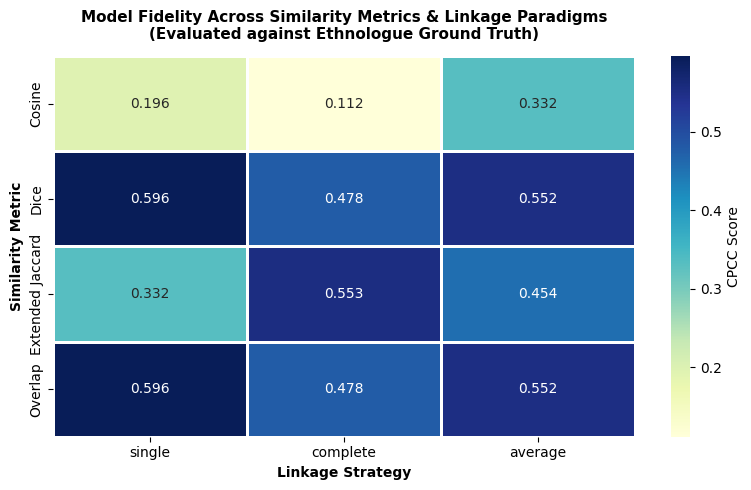

In [125]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Pivot results into a clean 4x3 Matrix (Metrics vs Linkages)
# FIXED: Replaced "CPCC vs Ethnologue" with "Ethnologue Match (vs Ethno)"
cpcc_matrix = results_df.pivot(
    index="Metric", 
    columns="Linkage", 
    values="Ethnologue Match (vs Ethno)" 
)[["single", "complete", "average"]] # Re-order columns logically

# Re-order rows logically
cpcc_matrix = cpcc_matrix.reindex(["Cosine", "Dice", "Extended Jaccard", "Overlap"])

print("=== CPCC EVALUATION MATRIX (vs Ethnologue Ground Truth) ===")
print(cpcc_matrix.to_markdown())

# 2. Identify and print the Champion
champion_metric = results_df.iloc[0]["Metric"]
champion_linkage = results_df.iloc[0]["Linkage"]
# FIXED: Replaced "CPCC vs Ethnologue" with "Ethnologue Match (vs Ethno)"
champion_score = results_df.iloc[0]["Ethnologue Match (vs Ethno)"] 

print(f"\n🏆 CHAMPION MODEL: {champion_metric} + {champion_linkage.upper()} (CPCC = {champion_score:.4f})")

# 3. Generate a High-Resolution Heatmap for Defense Slides / Manuscript
plt.figure(figsize=(8, 5))
sns.heatmap(
    cpcc_matrix, 
    annot=True, 
    fmt=".3f", 
    cmap="YlGnBu", 
    cbar_kws={'label': 'CPCC Score'},
    linewidths=1,
    linecolor='white'
)

plt.title("Model Fidelity Across Similarity Metrics & Linkage Paradigms\n(Evaluated against Ethnologue Ground Truth)", fontsize=11, fontweight='bold', pad=12)
plt.xlabel("Linkage Strategy", fontweight='bold')
plt.ylabel("Similarity Metric", fontweight='bold')
plt.tight_layout()

# Save image for your thesis writeup
plt.savefig("cpcc_model_evaluation_matrix.png", dpi=300)
plt.show()